# bxai
### Bayesian Feature Selection and Attribution Suite

### Load Data

In [1]:
from sklearn.datasets import load_breast_cancer

# Load Breast Cancer dataset
data = load_breast_cancer(as_frame=True)
X, y = data.data, data.target
print(f"{len(X)} Rows and {len(X.columns)} Columns")

569 Rows and 30 Columns


## 1. Global Non-Linear Selection: `BayesianBorutaSHAP`

`BayesianBorutaSHAP` performs tree-based feature selection using SHAP values, replacing frequentist p-values with Bayesian credible intervals. It supports both discrete (Beta-Binomial) and continuous (Normal-Inverse-Gamma) modes.

In [4]:
import lightgbm as lgb
from bxai.selection import BayesianBorutaSHAP

# Fit Bayesian BorutaSHAP
clf = lgb.LGBMClassifier(random_state=42, verbose=-1)
selector = BayesianBorutaSHAP(model=clf, 
                                mode="discrete", 
                                max_iter=100,
                                confirm_threshold=0.95,
                                reject_threshold=0.05,
                                early_stopping=False,
                                random_state=42)
selector.fit(X, y)

print("Confirmed Features:", selector.confirmed_)
selector.summary().sort_values(by= ['status', 'mean']).reset_index(drop=True)

Confirmed Features: ['mean texture', 'mean smoothness', 'mean concave points', 'area error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst concavity', 'worst concave points']


,feature,status,mean,ci_lower,ci_upper,alpha,beta
0,mean smoothness,Confirmed,0.627451,0.531931,0.718235,64.0,38.0
1,worst radius,Confirmed,0.696078,0.603853,0.781021,71.0,31.0
2,worst smoothness,Confirmed,0.960784,0.915643,0.989106,98.0,4.0
3,mean texture,Confirmed,0.980392,0.946068,0.997593,100.0,2.0
4,mean concave points,Confirmed,0.990196,0.964135,0.999749,101.0,1.0
5,area error,Confirmed,0.990196,0.964135,0.999749,101.0,1.0
6,worst texture,Confirmed,0.990196,0.964135,0.999749,101.0,1.0
7,worst perimeter,Confirmed,0.990196,0.964135,0.999749,101.0,1.0
8,worst area,Confirmed,0.990196,0.964135,0.999749,101.0,1.0
9,worst concavity,Confirmed,0.990196,0.964135,0.999749,101.0,1.0


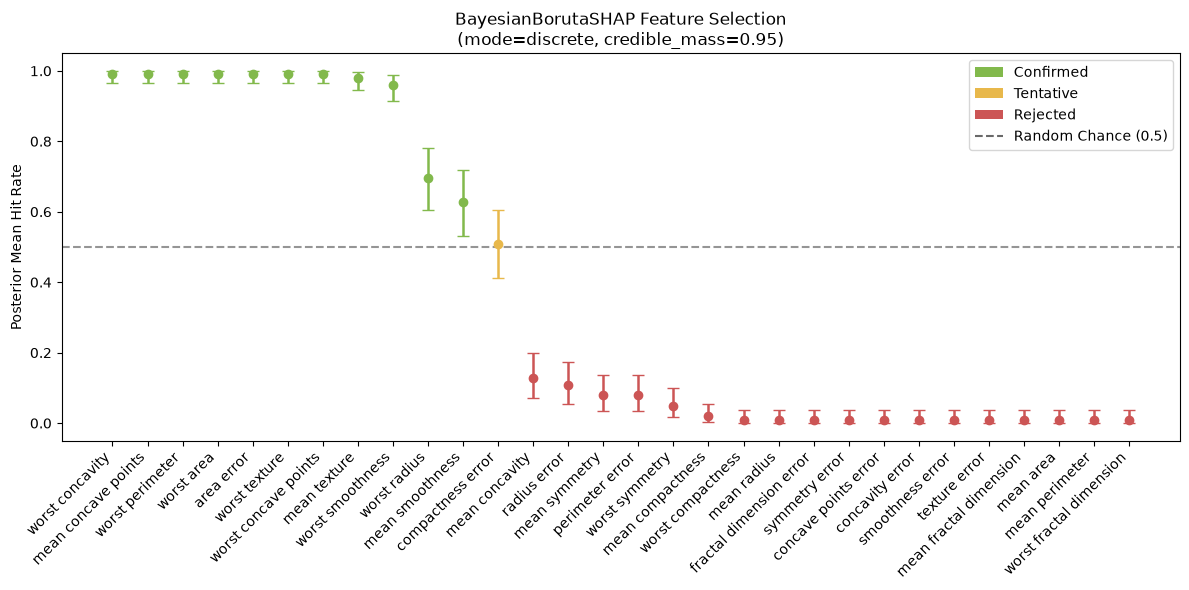

In [5]:
# Visualize selection results (Mean and CIs)
fig = selector.plot()

## 2. Global Non-Linear Selection: `BayesianPermutation`

`BayesianPermutation` is a model-agnostic feature selection tool that tracks importance using paired validation loss drops updated via the Student-t continuous engine.

In [15]:
from bxai.selection import BayesianPermutation
from sklearn.ensemble import RandomForestClassifier

# Fit classifier
clf_perm = RandomForestClassifier(random_state=42, verbose=0).fit(X.values, y)

# Permutation feature selection with parallel jobs (n_jobs=2)
selector_perm = BayesianPermutation(
    model=clf_perm,
    scoring="accuracy",
    n_repeats=100,
    n_jobs=2,
    random_state=42,
)
selector_perm.fit(X, y)

print("Confirmed Features:", selector_perm.confirmed_)
selector_perm.summary().sort_values(by =['status', 'mean'], ascending =[True, False]).reset_index(drop=True)

Confirmed Features: ['mean texture', 'mean concave points', 'radius error', 'area error', 'compactness error', 'worst texture', 'worst area', 'worst smoothness', 'worst concave points']


,feature,status,mean,hdi_lower,hdi_upper,nu,alpha,beta
0,mean concave points,Confirmed,0.002654,0.002254,0.003054,100.0001,50.0001,0.000203
1,mean texture,Confirmed,0.002285,0.001926,0.002643,100.0001,50.0001,0.000163
2,worst texture,Confirmed,0.001564,0.001263,0.001865,100.0001,50.0001,0.000115
3,radius error,Confirmed,0.001388,0.001074,0.001703,100.0001,50.0001,0.000126
4,compactness error,Confirmed,0.001336,0.001018,0.001653,100.0001,50.0001,0.000128
5,worst concave points,Confirmed,0.001318,0.000960,0.001676,100.0001,50.0001,0.000163
6,worst area,Confirmed,0.001213,0.000860,0.001565,100.0001,50.0001,0.000158
7,area error,Confirmed,0.001160,0.000834,0.001486,100.0001,50.0001,0.000135
8,worst smoothness,Confirmed,0.000562,0.000238,0.000887,100.0001,50.0001,0.000134
9,mean concavity,Tentative,0.000105,-0.000187,0.000398,100.0001,50.0001,0.000109


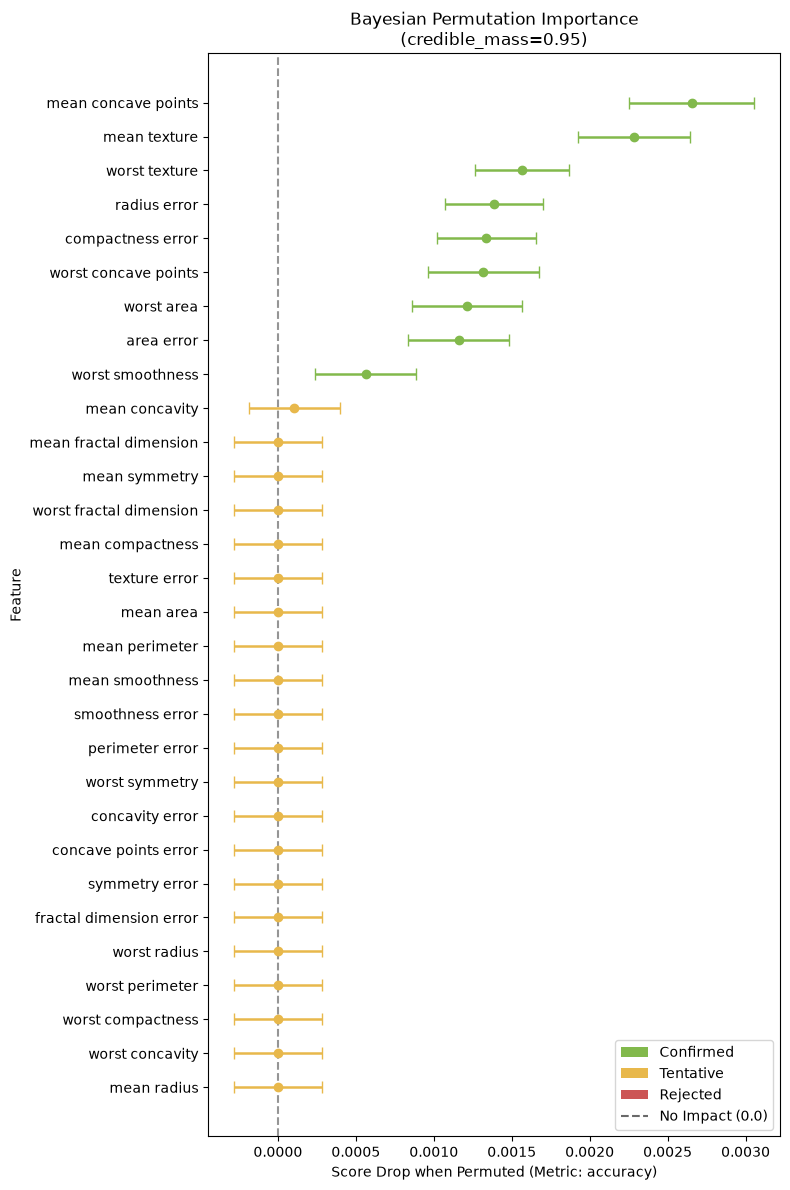

In [16]:
# Visualize permutation importance results (Mean and HDIs)
fig = selector_perm.plot(max_features=None)

## 3. Local Interpretability: `BayLIME`

`BayLIME` generates stable, prior-informed local explanations wrapping standard or custom perturbations in a Bayesian linear regression.

In [21]:
from bxai.explanation import BayLIME
import lightgbm as lgb
import numpy as np

# 1. Fit the selector to get the priors
clf = lgb.LGBMClassifier(random_state=42, verbose=-1)

# 2. Instantiate BayLIME
explainer = BayLIME(
    training_data=X,
    feature_names=list(X.columns),
    backend = 'mcmc'
)

# 3. Fit the base model before explaining (since BorutaSHAP clones the model internally)
clf.fit(X, y)

# 4. Explain a single instance
explanation = explainer.explain_instance(
    instance=X.iloc[0].values,
    predict_fn=clf.predict_proba
)

explanation.as_dataframe().sort_values(by=['mean'])

/Users/sam/Locals Only/bxai/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [intercept, coefs, sigma_global]
Sampling 2 chains for 500 tune and 1_000 draw iterations (1_000 + 2_000 draws total) took 87 seconds.
There were 1876 divergences after tuning. Increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


,feature,mean,std,hdi_lower,hdi_upper,value,backend
0,concave points error,-0.982068,0.006580,-0.988655,-0.975488,0.015870,mcmc
1,perimeter error,-0.774303,0.081589,-0.855916,-0.692731,8.589000,mcmc
2,smoothness error,-0.744614,0.146593,-0.891172,-0.598027,0.006399,mcmc
3,worst smoothness,-0.714487,0.077651,-0.792120,-0.636853,0.162200,mcmc
6,texture error,-0.631171,0.205074,-0.836199,-0.426129,0.905300,mcmc
8,concavity error,-0.552633,0.031755,-0.584394,-0.520886,0.053730,mcmc
12,mean compactness,-0.463662,0.389610,-0.853186,-0.074150,0.277600,mcmc
13,worst concave points,-0.454572,0.430724,-0.885191,-0.023951,0.265400,mcmc
17,symmetry error,-0.294902,0.030380,-0.325274,-0.264528,0.030030,mcmc
20,worst radius,-0.132683,0.045021,-0.177473,-0.080083,25.380000,mcmc


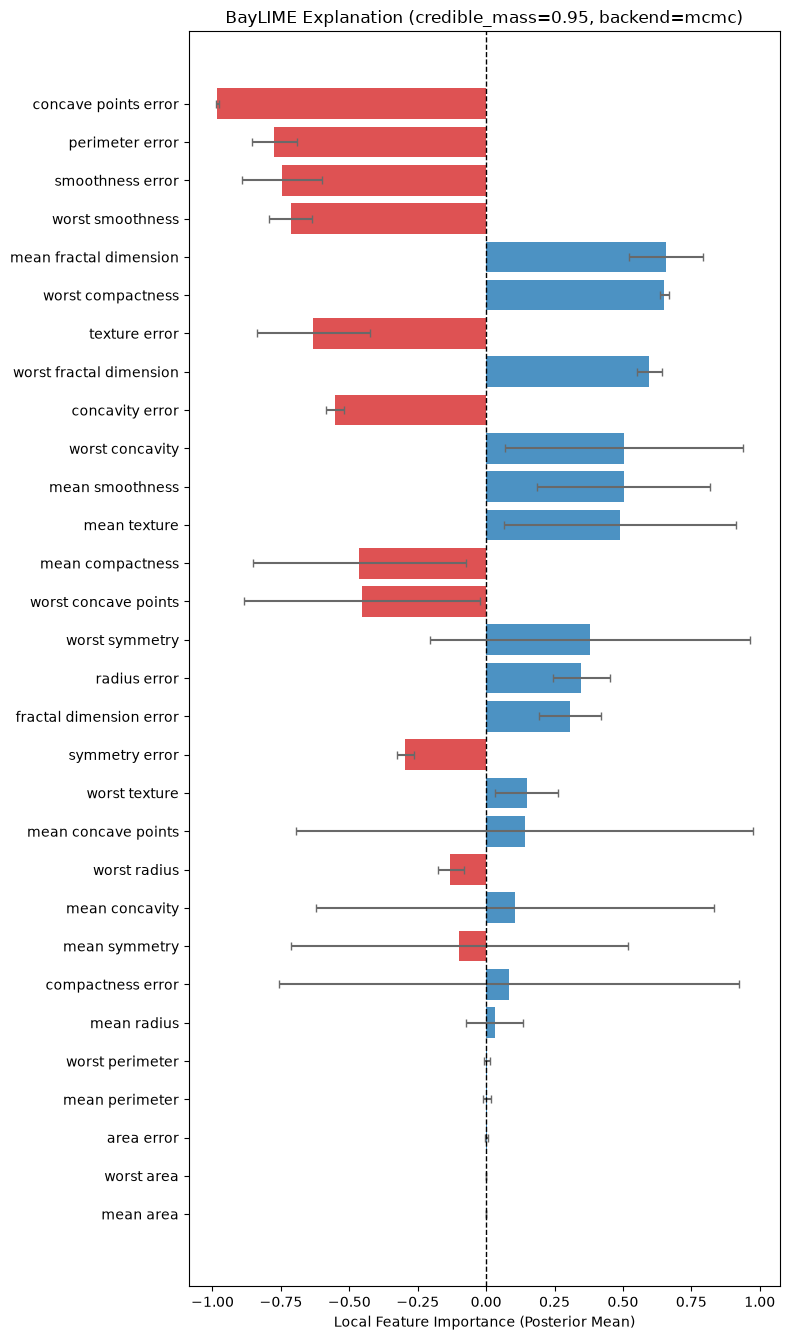

In [24]:
# Visualize the local explanation (comparing global prior vs local posterior)
fig = explanation.plot(max_features=None)

### Use BayesianBorutaSHAP Global Importance to build the Priors for BayLIME Local Importance

In [25]:
import lightgbm as lgb
from bxai.selection import BayesianBorutaSHAP
from bxai.explanation import BayLIME

# 1. Fit the selector to get the priors
clf = lgb.LGBMClassifier(random_state=42, verbose=-1)
selector = BayesianBorutaSHAP(model=clf, mode="discrete", max_iter=100, random_state=42)
selector.fit(X, y)

# 2. Fit the original model so it can make predictions for the explainer
clf.fit(X, y)  # <-- ADD THIS LINE to fit clf on the data

# 3. Instantiate BayLIME with the priors
explainer = BayLIME(
    training_data=X,
    feature_names=list(X.columns),
    prior_mean=selector.feature_importances_, # <-- Feeds the global SHAP priors here!
    prior_precision=1.0,                      # Adjust the strength of the prior 0 to inf
    backend='mcmc'
)

# 4. Explain a single instance
explanation = explainer.explain_instance(
    instance=X.iloc[0].values,
    predict_fn=clf.predict_proba
)

explanation.as_dataframe().sort_values(by=['mean'])

/Users/sam/Locals Only/bxai/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/sam/Locals Only/bxai/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [intercept, coefs, sigma_global]
Sampling 2 chains for 500 tune and 1_000 draw iterations (1_000 + 2_000 draws total) took 244 seconds.
There were 983 divergences after tuning. Increase `target_accept` or reparameterize.
Chain 1 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat

,feature,mean,std,hdi_lower,hdi_upper,value,backend
8,texture error,-0.362452,0.354181,-0.732357,-0.008472,0.905300,mcmc
9,perimeter error,-0.327009,0.328564,-0.655483,0.005753,8.589000,mcmc
10,worst symmetry,-0.297487,0.246778,-0.544691,-0.050770,0.460100,mcmc
11,concave points error,-0.264505,0.335104,-0.600050,0.070517,0.015870,mcmc
19,symmetry error,-0.092631,0.069274,-0.161888,-0.023065,0.030030,mcmc
22,worst radius,-0.022558,0.029110,-0.051960,0.008355,25.380000,mcmc
23,compactness error,-0.015505,0.077509,-0.092995,0.062158,0.049040,mcmc
24,worst texture,-0.014877,0.011498,-0.026455,-0.001700,17.330000,mcmc
25,mean perimeter,-0.003012,0.004061,-0.007069,0.001412,122.800000,mcmc
26,worst perimeter,-0.002076,0.003045,-0.005146,0.001211,184.600000,mcmc


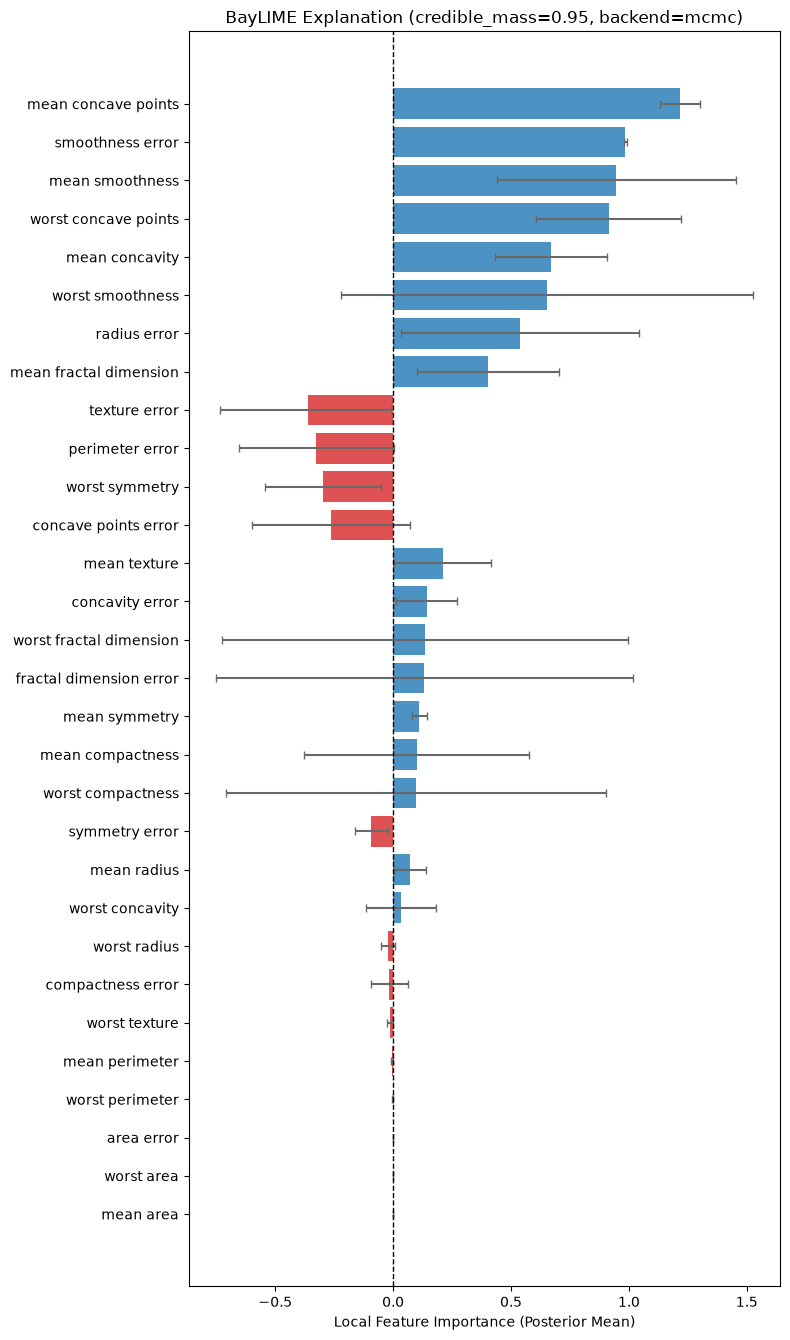

In [27]:
# Visualize the local explanation (comparing global prior vs local posterior)
fig = explanation.plot(max_features=None)

## 4. Parametric Selection: `ShrinkagePIP`

`ShrinkagePIP` implements high-dimensional generalized linear models (GLMs) using Horseshoe and Lasso regularizing priors, tracking Posterior Inclusion Probabilities (PIP) to select features.

In [ ]:
from bxai.parametric import ShrinkagePIP

# Horseshoe prior — uses kappa-based PIP by default (pip_method="auto")
selector_hs = ShrinkagePIP(
    model_type="logistic",
    prior="horseshoe",
    kappa_threshold=0.5,   # k < 0.5 -> local scale dominates -> signal
    pip_threshold=0.80,
    n_samples=100,
    random_state=42,
)
selector_hs.fit(X, y)

print("\nSelected features (Horseshoe):", selector_hs.confirmed_)
display(selector_hs.summary().sort_values(by = ["selected", "mean"], ascending=[False, True]).reset_index(drop=True))


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [intercept, tau, lambdas, beta]
Sampling 2 chains for 1_000 tune and 500 draw iterations (2_000 + 1_000 draws total) took 1 seconds.
There were 1000 divergences after tuning. Increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details



Selected features (Horseshoe): ['symmetry error']


,feature,pip,pip_method,selected,mean,std,hdi_lower,hdi_upper,interval_type,kappa_mean
0,symmetry error,1.0,kappa,True,0.751837,0.139006,0.612831,0.890844,hdi,0.405984
1,perimeter error,0.0,kappa,False,-0.787629,0.051565,-0.839194,-0.736064,hdi,0.835657
2,mean symmetry,0.0,kappa,False,-0.772494,0.026022,-0.798516,-0.746471,hdi,0.847167
3,concave points error,0.0,kappa,False,-0.609270,0.163216,-0.772487,-0.446054,hdi,0.744459
4,worst smoothness,0.5,kappa,False,-0.366689,0.178094,-0.544783,-0.188595,hdi,0.625190
5,concavity error,0.5,kappa,False,-0.352199,0.140979,-0.493179,-0.211219,hdi,0.605885
6,mean concave points,0.0,kappa,False,-0.334074,0.607242,-0.941317,0.273168,hdi,0.786244
7,compactness error,0.5,kappa,False,-0.281135,0.351802,-0.632938,0.070667,hdi,0.507739
8,worst concavity,0.5,kappa,False,-0.269869,0.324870,-0.594739,0.055001,hdi,0.478946
9,smoothness error,0.5,kappa,False,-0.246063,0.413636,-0.659700,0.167573,hdi,0.624691


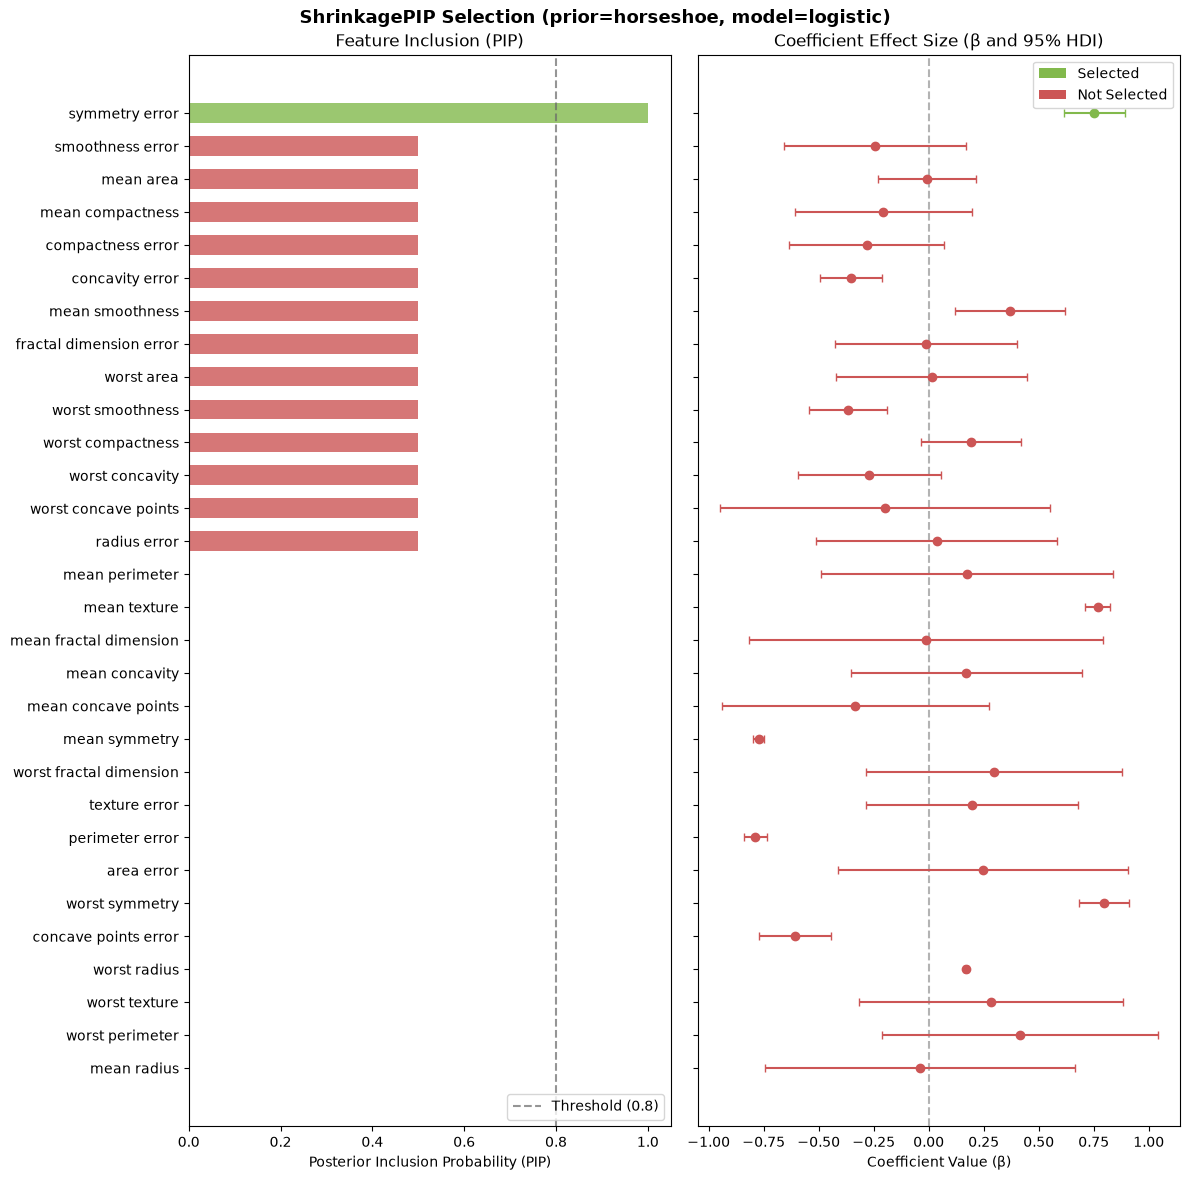

In [17]:
# Visualize the PIP and Coeff Effect Size
fig = selector_hs.plot(max_features=None)

In [ ]:
# Lasso prior — uses auto-scaled |B| threshold (epsilon = 0.1)
selector_lasso = ShrinkagePIP(
    model_type="logistic",
    prior="lasso",
    pip_threshold=0.80,
    n_samples=100,
    random_state=42,
)
selector_lasso.fit(X, y)
print(f"\nEffective epsilon: {selector_lasso.epsilon_:.4f}")
print("\nSelected features (LASSO):", selector_lasso.confirmed_)
display(selector_lasso.summary().sort_values(by = ["selected", "mean"], ascending=[False, True]).reset_index(drop=True))

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [intercept, b, beta]
Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 1 seconds.
There were 2000 divergences after tuning. Increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details



Effective epsilon: 0.1000

Selected features (LASSO): ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst concave points', 'worst symmetry', 'worst fractal dimension']


,feature,pip,pip_method,selected,mean,std,hdi_lower,hdi_upper,interval_type,epsilon
0,perimeter error,1.0,threshold,True,-0.788653,0.052589,-0.841243,-0.736064,hdi,0.1
1,mean symmetry,1.0,threshold,True,-0.772368,0.026147,-0.798516,-0.746219,hdi,0.1
2,concave points error,1.0,threshold,True,-0.608099,0.162044,-0.770144,-0.446054,hdi,0.1
3,worst smoothness,1.0,threshold,True,-0.364830,0.176236,-0.541068,-0.188595,hdi,0.1
4,concavity error,1.0,threshold,True,-0.349920,0.138700,-0.488621,-0.211219,hdi,0.1
5,mean concave points,1.0,threshold,True,-0.335734,0.608902,-0.944637,0.273168,hdi,0.1
6,smoothness error,1.0,threshold,True,-0.247551,0.415124,-0.662675,0.167573,hdi,0.1
7,mean compactness,1.0,threshold,True,-0.205665,0.401563,-0.607229,0.195898,hdi,0.1
8,worst concave points,1.0,threshold,True,-0.199567,0.749168,-0.948735,0.549601,hdi,0.1
9,mean radius,1.0,threshold,True,-0.041527,0.704704,-0.746232,0.663177,hdi,0.1


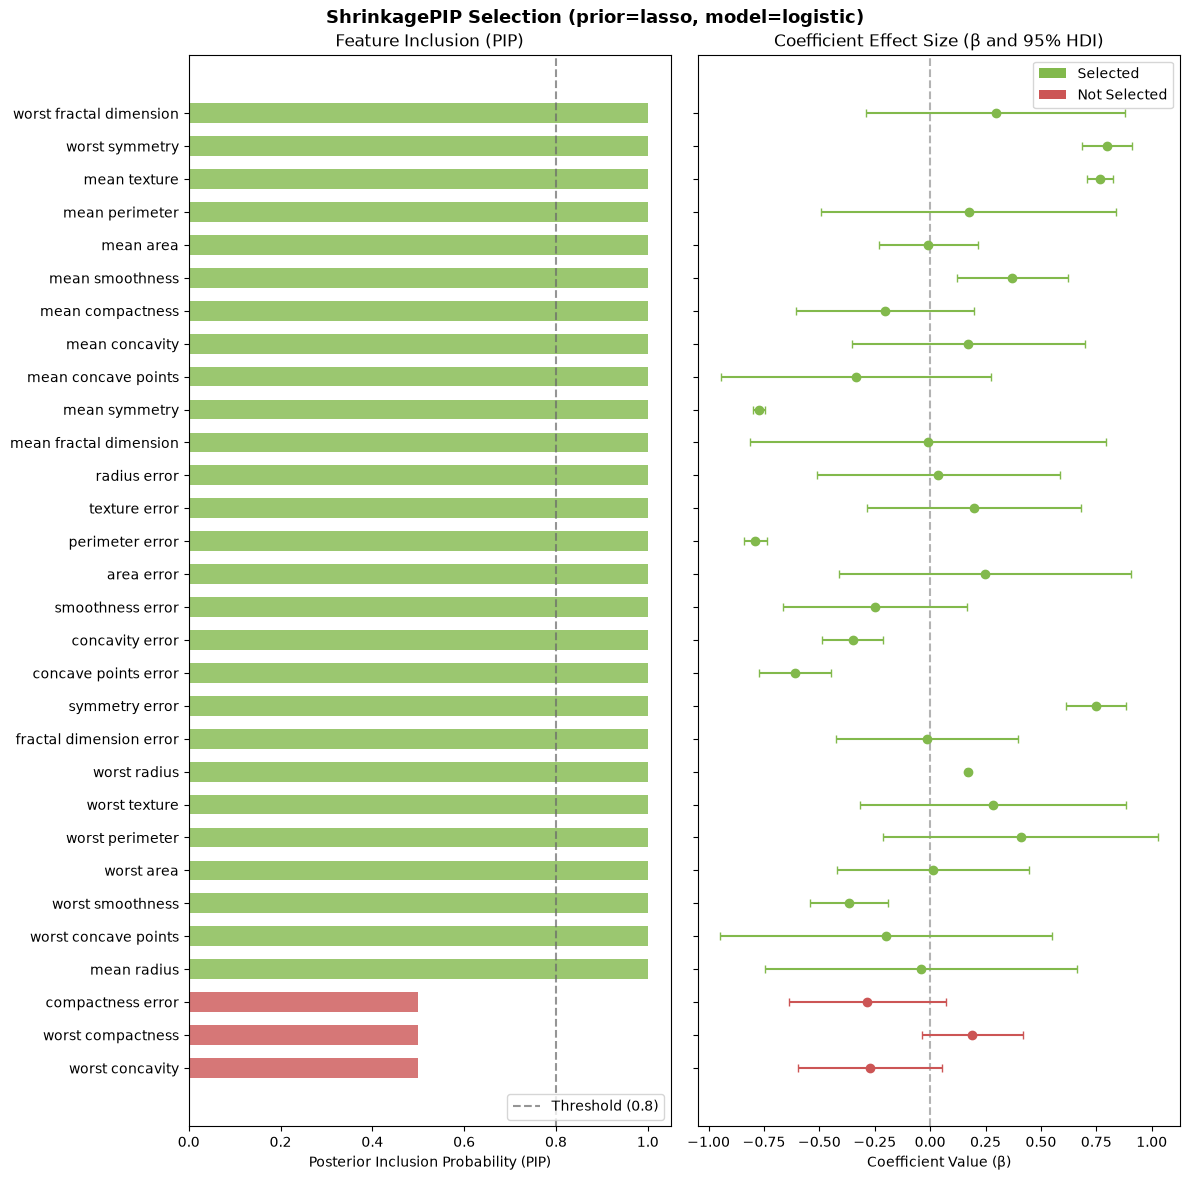

In [16]:
# Visualize the PIP and Coeff Effect Size
fig = selector_lasso.plot(max_features=None)

## 5. Native Bayesian Importance: `BARTImportance`

`BARTImportance` tracks Variable Inclusion Frequencies (VIF) from native Bayesian Additive Regression Trees (BART) models to estimate feature importance.

In [6]:
from bxai.parametric import BARTImportance

# Classification example (Probit BART)
bart_clf = BARTImportance(model_type="classification", 
                            n_trees=500, 
                            n_samples=50, 
                            tune=100, 
                            chains=1, 
                            random_state=42)
bart_clf.fit(X, y)
print("Classification Selected features:", bart_clf.confirmed_)

Only 50 samples per chain. Reliable r-hat and ESS diagnostics require longer chains for accurate estimate.
Sequential sampling (1 chains in 1 job)
PGBART: [mu]
Sampling 1 chain for 100 tune and 50 draw iterations (100 + 50 draws total) took 18 seconds.
The number of samples is too small to check convergence reliably.


Classification Selected features: []


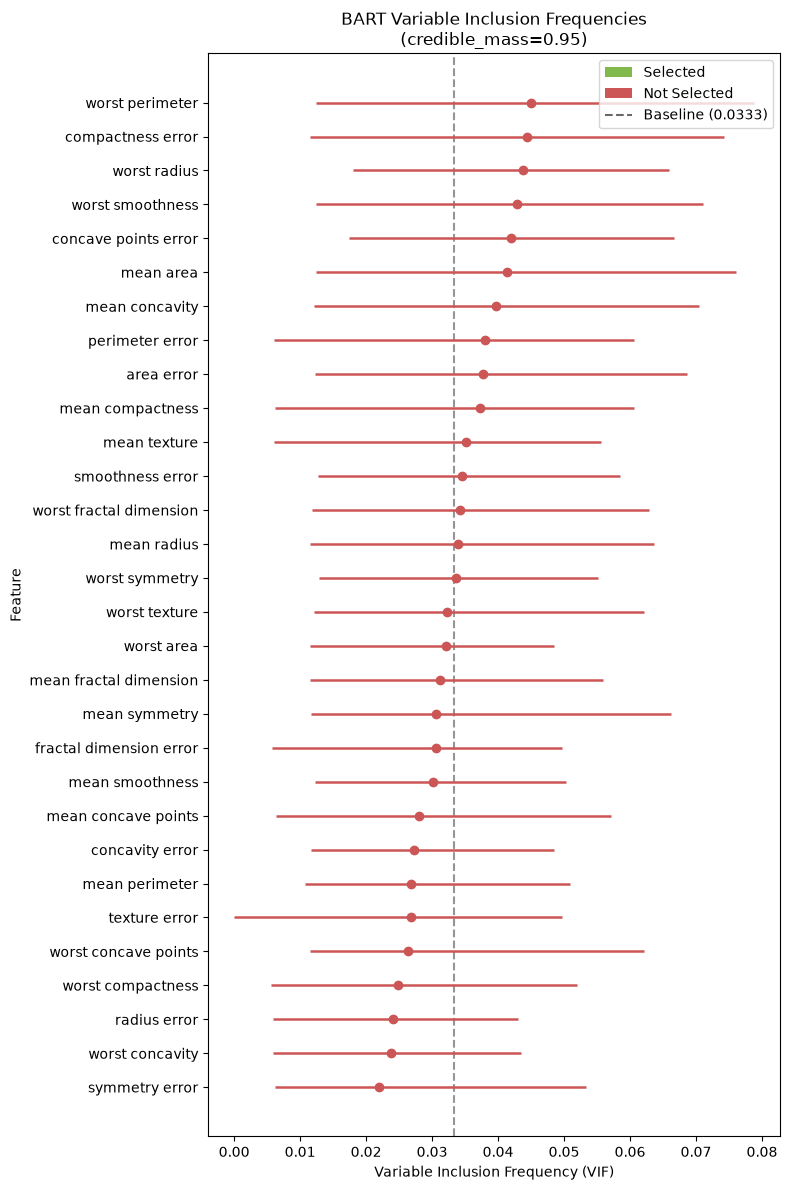

In [7]:
# Visualize VIF posterior means and credible intervals
fig = bart_clf.plot(max_features=None)